TASK 1
- Visualize sample images
- Analyze class distribution and imbalance
- Discuss resolution, image quality, color channels
- Prepare train/validation/test-splits

In [1]:
# Load data
import kagglehub
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

# Path contents
from pathlib import Path
path = Path("/kaggle/input/new-plant-diseases-dataset")

# Paths
main = path / "New Plant Diseases Dataset(Augmented)"
train_validation_folder = main / "New Plant Diseases Dataset(Augmented)"
test_folder = path / "test"

# Data (1.4)
train_data = train_validation_folder / "train"
#for items in train_data.iterdir():
  #print("Training data:\n",items.name)

validation_data = train_validation_folder / "valid"
#for items in validation_data.iterdir():
# print("Validation data:\n", items.name)

test_data = train_validation_folder / "valid"
#for items in test_data.iterdir():
#  print("Test data:\n", items.name)


100%|██████████| 2.70G/2.70G [01:28<00:00, 32.7MB/s]

Extracting files...


3 SAMPLES FROM TRAINING DATA:
{PosixPath('Tomato___Late_blight/c4f45383-715a-48b2-8ec7-c45d1c230a9d___GHLB_PS Leaf 13.1 Day 7.jpg')}


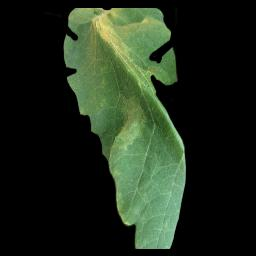

{PosixPath('Tomato___Late_blight/d2ef0edd-4a4f-4245-85a8-34309ef9ef71___GHLB_PS Leaf 46.1 Day 18.jpg')}


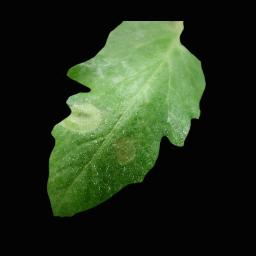

{PosixPath('Tomato___Late_blight/121097dd-b0cb-436b-9b2f-7dab30c86872___GHLB_PS Leaf 37.1 Day 13.jpg')}


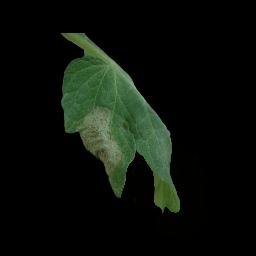

3 SAMPLES FROM TEST DATA:
{PosixPath('TomatoEarlyBlight6.JPG')}


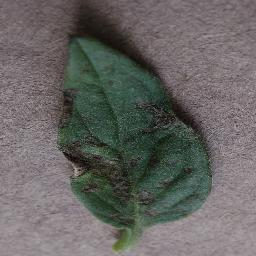

{PosixPath('TomatoYellowCurlVirus4.JPG')}


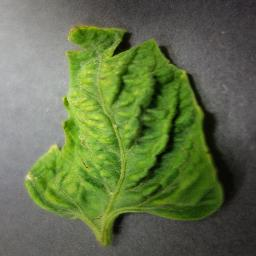

{PosixPath('TomatoYellowCurlVirus6.JPG')}


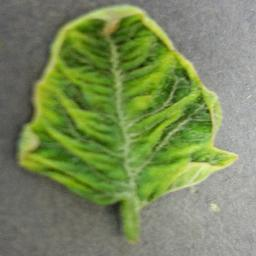

3 SAMPLES FROM VALIDATION DATA:
{PosixPath('Tomato___Late_blight/3b34322e-e2ad-4023-bf76-f290fb2455a1___GHLB_PS Leaf 52 Day 18_flipLR.jpg')}


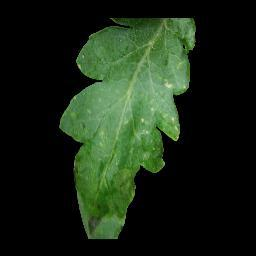

{PosixPath('Tomato___Late_blight/1cb5d336-3649-49bf-aa9a-72950067b8b0___GHLB_PS Leaf 12 Day 9_flipLR.jpg')}


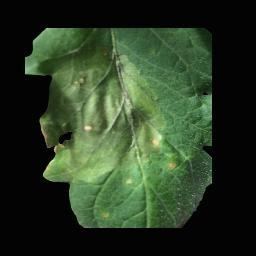

{PosixPath('Tomato___Late_blight/4bf424a2-b275-4ac0-968c-fe229136f10d___GHLB_PS Leaf 2.5 Day 16.jpg')}


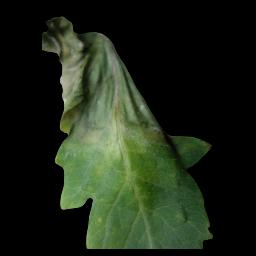

In [ ]:
# 1.1: Visualize sample images

from PIL import Image
from IPython.display import display

def display_sample_images(folder_path: Path, max_images: int = 3, title: str = "Dataset"):
  print(f"{max_images} SAMPLES FROM {title}:")
  images_files = list(folder_path.rglob("*.jpg")) # Find all images
  images_files.extend(list(folder_path.rglob("*.JPG")))

  images_to_show = images_files[:max_images]

  for image_path in images_to_show:
    print({image_path.relative_to(folder_path)})

    img = Image.open(image_path)
    display(img)

# Train samples
display_sample_images(train_data, max_images = 3, title = "TRAINING DATA")
display_sample_images(test_data, max_images = 3, title = "TEST DATA")
display_sample_images(validation_data, max_images = 3, title = "VALIDATION DATA")



In [ ]:
# TASK 1.2: Analyze class distribution and imbalance
  # Number of unique classes
train_length = print("Training data lenght:", len(
    [l for l in train_data.rglob("*") if l.suffix.lower() in ('.jpg')]))
test_length = print("Test data length:", len(
    [l for l in test_data.rglob("*") if l.suffix.lower() in ('.jpg')]))
valid_length = print("Validation data length:", len(
    [l for l in validation_data.rglob("*") if l.suffix.lower() in ('.jpg')]))

print()

# TASK 1.3: Discuss resolution, image quality, color channels

# Image size inspection
def get_resolution(image_path: Path):
  with Image.open(image_path) as img:
    return img.size

train_image = train_data / "Tomato___Late_blight"
get_res_train = next(train_image.rglob("*.jpg"))
width, height = get_resolution(get_res_train)
print(f"Test image resolution: {width}x{height}")

test_image = test_data / "TomatoEarlyBlight6.JPG"
get_res_test = next(train_image.rglob("*.JPG"))
width, height = get_resolution(get_res_test)
print(f"Train image resolution: {width}x{height}")

val_image = test_data / "Tomato___Late_blight"
get_res_val = next(train_image.rglob("*.jpg"))
width, height = get_resolution(get_res_val)
print(f"Validation image resolution: {width}x{height}")
print()

# Extract color channels - all images on average
def extract_color_channels(image_path: Path):
  img_bgr = cv2.imread(str(image_path))

  if img_bgr is None:
    return 0, 0, 0, 0

  height, width, _ = img_bgr.shape
  pixel_count = height * width

  b_channel, g_channel, r_channel = cv2.split(img_bgr)

  b_sum = np.sum(b_channel)
  g_sum = np.sum(g_channel)
  r_sum = np.sum(r_channel)

  return b_sum, g_sum, r_sum, pixel_count

train_folder = list(train_data.rglob("*.jpg"))
test_folder = list(test_data.rglob("*.JPG"))
val_folder = list(validation_data.rglob("*.jpg"))
all_image_folders = train_folder + test_folder + val_folder

total_b_sum = 0
total_g_sum = 0
total_r_sum = 0
total_pixels = 0

for i, image_path in enumerate(all_image_folders):
  b_sum_img, g_sum_img, r_sum_img, pixel_count_img = extract_color_channels(image_path)


  total_b_sum += b_sum_img
  total_g_sum += g_sum_img
  total_r_sum += r_sum_img
  total_pixels += pixel_count_img


if total_pixels == 0:
  print("Error")
else:
  avg_b = total_b_sum / total_pixels
  avg_g = total_g_sum / total_pixels
  avg_r = total_r_sum / total_pixels

print(f"Red channels on average: {avg_r:.2f}")
print(f"Blue channels on average: {avg_b:.2f}")
print(f"Green channels on average: {avg_g:.2f}")
print()

# Qualitification of image quality (using Laplacian variance)
import cv2
import numpy as np

def quality_sharpness(image_path: Path):
  img_cv = cv2.imread(str(image_path))

  # Since sharpness works best via single channel, convert to grayscale
  gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

  # Calculate variance
  laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
  return laplacian_var

# Sharpness score: training images
sharpness_scores = []
low_quality_count = 0
low_quality_threshold = 100

train_images = list(train_data.rglob("*.jpg"))
total_images = len(train_images)

for i, image_path in enumerate(train_images):
  score = quality_sharpness(image_path)
  sharpness_scores.append(score)

  if score < low_quality_threshold:
    low_quality_count += 1

print("TRAINING DATA SHARPNESS: ")
print(f"Images below sharpness threshold: {low_quality_count}")
print(f"Percentage of low images: {(low_quality_count / total_images * 100):.2f}%")

# Sharpness score: test images
sharpness_scores = []
low_quality_count = 0
low_quality_threshold = 100

test_images = list(test_data.rglob("*.JPG"))
total_images = len(test_images)

for i, image_path in enumerate(test_images):
  score = quality_sharpness(image_path)
  sharpness_scores.append(score)

  if score < low_quality_threshold:
    low_quality_count += 1

print("TEST DATA SHARPNESS: ")
print(f"Images below sharpness threshold: {low_quality_count}")
print(f"Percentage of low images: {(low_quality_count / total_images * 100):.2f}%")

# Sharpness score: validation images
sharpness_scores = []
low_quality_count = 0
low_quality_threshold = 100

val_images = list(validation_data.rglob("*.jpg"))
total_images = len(val_images)

for i, image_path in enumerate(val_images):
  score = quality_sharpness(image_path)
  sharpness_scores.append(score)

  if score < low_quality_threshold:
    low_quality_count += 1

print("VALIDATION DATA SHARPNESS: ")
print(f"Images below sharpness threshold: {low_quality_count}")
print(f"Percentage of low images: {(low_quality_count / total_images * 100):.2f}%")


Training data lenght: 70333
Test data length: 33
Validation data length: 17610

Test image resolution: 256x256
Train image resolution: 256x256
Validation image resolution: 256x256

Red channels on average: 120.34
Blue channels on average: 110.91
Green channels on average: 147.76

TRAINING DATA SHARPNESS: 
Images below sharpness threshold: 419
Percentage of low images: 17.12%
TEST DATA SHARPNESS: 
Images below sharpness threshold: 2
Percentage of low images: 6.06%
VALIDATION DATA SHARPNESS: 
Images below sharpness threshold: 104
Percentage of low images: 17.36%


**Discuss resolution, image quality, color channels**

- Image resolution: 256x256
- 70333 images in train, 33 in test, 17610 in val
- 17% of images in both training and validation are not up to par in terms of sharpness whilst only 6% of the test images are not
- Red channels: 120, Blue channels: 111 , Green channels: 148

In [2]:
# Data preparation
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_transforms = transforms.Compose([
    #transforms.Resize((224, 224)), # hash out when refining CNN
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet norm constants - okie for resnet/mbnet
])

train_dataset = datasets.ImageFolder(root = train_data, transform = data_transforms)
valid_dataset = datasets.ImageFolder(root = validation_data, transform = data_transforms)
test_dataset = datasets.ImageFolder(root = test_data, transform = data_transforms)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True, num_workers = 2)
val_loader = DataLoader(valid_dataset, batch_size = 32, shuffle = True, num_workers = 2)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = True, num_workers = 2)



TASK 2.1: Train custom CNN model
- Multiple convolutional blocks
- Experiment with different number of filters, kernel sizes, stride, paddings, activation function etc
- Do an optimisation comparison between ADAM and SGD with different learning rates
- Implement Dropout, batch normalization, global average pooling

In [3]:
import torch
import torch.nn as nn

# TASK 2.1
# Define model
class PlantDisease(nn.Module):
  def __init__(self, in_channels, num_classes):
    super().__init__()
    self.CNN = nn.Sequential(
        nn.Conv2d(in_channels = in_channels, out_channels = 32, kernel_size = 3, padding = 1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2),


        nn.Conv2d(32, 64, kernel_size = 3, stride = 1, padding = 1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(64, 128, kernel_size = 3, stride = 2, padding = 1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.AdaptiveMaxPool2d(1),

    )

    self.Classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.BatchNorm1d(256),
        nn.Linear(256, num_classes)
    )

  def forward(self, x):
    features = self.CNN(x)
    logits = self.Classifier(features)
    return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PlantDisease(3, 38).to(device)

# Criterion
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4)

# Training
epoch_number = 20
for epoch in range(epoch_number):
  model.train()

  running_loss = 0
  train_correct = 0
  train_total = 0

  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = loss_fn(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    _, predicted = torch.max(outputs.data, 1)
    train_total += labels.size(0)
    train_correct += (predicted == labels).sum().item()

  print(f"Epoch: {epoch + 1}/{epoch_number} | Loss: {running_loss / len(train_loader):.4f} | Accuracy: {100 * train_correct / train_total:.2f}%")

Epoch: 1/20 | Loss: 2.5239 | Accuracy: 36.81%
Epoch: 2/20 | Loss: 1.2933 | Accuracy: 68.10%
Epoch: 3/20 | Loss: 0.8291 | Accuracy: 78.44%
Epoch: 4/20 | Loss: 0.6248 | Accuracy: 83.11%
Epoch: 5/20 | Loss: 0.5146 | Accuracy: 85.75%
Epoch: 6/20 | Loss: 0.4321 | Accuracy: 87.68%
Epoch: 7/20 | Loss: 0.3961 | Accuracy: 88.74%
Epoch: 8/20 | Loss: 0.3572 | Accuracy: 89.51%
Epoch: 9/20 | Loss: 0.3409 | Accuracy: 90.02%
Epoch: 10/20 | Loss: 0.3238 | Accuracy: 90.50%
Epoch: 11/20 | Loss: 0.2964 | Accuracy: 91.33%
Epoch: 12/20 | Loss: 0.2897 | Accuracy: 91.43%
Epoch: 13/20 | Loss: 0.2675 | Accuracy: 91.87%
Epoch: 14/20 | Loss: 0.2545 | Accuracy: 92.31%
Epoch: 15/20 | Loss: 0.2421 | Accuracy: 92.74%
Epoch: 16/20 | Loss: 0.2355 | Accuracy: 92.86%
Epoch: 17/20 | Loss: 0.2269 | Accuracy: 93.09%
Epoch: 18/20 | Loss: 0.2224 | Accuracy: 93.20%
Epoch: 19/20 | Loss: 0.2159 | Accuracy: 93.34%
Epoch: 20/20 | Loss: 0.2118 | Accuracy: 93.40%


To compare ADAM and SGD as well as experimenting with the parameters --> insert the results in an excel sheet

In [ ]:
# Evaluate
model.eval()

val_loss = 0
val_correct = 0
val_total = 0
best_val_acc = 0

with torch.no_grad():
  for images, labels in val_loader:
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    loss = loss_fn(outputs, labels)
    val_loss += loss.item()

    _, predicted = torch.max(outputs.data, 1)
    val_total += labels.size(0)
    val_correct += (predicted == labels).sum().item()

  avg_val_loss = val_loss / len(val_loader)
  val_accuracy = 100 * val_correct / val_total

  if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), 'best_plant_model.pth')
        print(f"Best model accuracy: {best_val_acc:.2f}% | Val loss: {avg_val_loss:.2f} ")

In [ ]:
#test
model.load_state_dict(torch.load('best_plant_model.pth'))
model.eval()

test_loss = 0
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = loss_fn(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()


avg_test_loss = test_loss / len(test_loader)
test_accuracy = 100 * test_correct / test_total

print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Test Loss: {avg_test_loss:.4f}")

TASK 2.2
- Test two pretrained architectures: ResNet&MobileNet
- Freeze vs finetune then compare

In [ ]:
  #ResNet18

# Load model directly
import torch
import torch.nn as nn
from transformers import AutoImageProcessor, AutoModelForImageClassification
processor = AutoImageProcessor.from_pretrained("microsoft/resnet-18")
model = AutoModelForImageClassification.from_pretrained("microsoft/resnet-18", num_labels = 38, ignore_mismatched_sizes = True)


# Freeze layers, unfreeze classifier
for param in model.parameters():
    param.requires_grad = False

# Define classifier + unfreeze it
in_features = model.classifier[-1].in_features # last layer
model.classifier = nn.Sequential(
    nn.Flatten(start_dim=1),
    nn.Linear(in_features, 38)
)

for param in model.classifier.parameters():
    param.requires_grad = True
!pip install evaluate -q

import evaluate
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred # model outputs, ground truth labels
    preds = logits.argmax(axis = -1) # convert raw logits into predicted class index
    return accuracy.compute(predictions = preds, references = labels)

def custom_collate_fn(batch): # Turn tuples into dictionaries
    pixel_values = torch.stack([item[0] for item in batch])
    labels = torch.tensor([item[1] for item in batch])
    return {
        "pixel_values": pixel_values,
        "labels": labels
    }


from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
training_args = TrainingArguments(
    output_dir = "./Resnetresults",
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 1e-3,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size = 32,
    num_train_epochs = 5,
    weight_decay = 0.01,
    load_best_model_at_end = True,
    metric_for_best_model = "accuracy"
)

trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset = valid_dataset,
    data_collator = custom_collate_fn,
    compute_metrics = compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)]
)

# Train the model
trainer.train()

# Get accuracy
results = trainer.evaluate()

print("Freeze results: ")
print("Accuracy: ", results['eval_accuracy'])
print("Loss: ", results['eval_loss'])

# Fine tuning Resnet

for name, param in model.named_parameters():
    if "layer3" in name or "layer4" in name or "classifier" in name: # Freeze last two layers + classifier - layers that handle complexity
      param.requires_grad = True
    else:
      param.requires_grad = False

training_args = TrainingArguments(
    output_dir = "./results",
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 1e-4, # Lower LR for stability
    per_device_train_batch_size = 32,
    per_device_eval_batch_size = 32,
    num_train_epochs = 10,
    weight_decay = 0.01,
    load_best_model_at_end = True,
    metric_for_best_model = "accuracy"

)

trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset = valid_dataset,
    data_collator = custom_collate_fn,
    compute_metrics = compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)]
)

trainer.train()

results = trainer.evaluate()

print("Fine-tuned results: ")
print("Accuracy: ", results['eval_accuracy'])
print("Loss: ", results['eval_loss'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

...

wandb: You chose "Don't visualize my results"


Epoch,Training Loss,Validation Loss,Accuracy
1,0.871100,0.666569,0.890280
2,0.503200,0.415662,0.914011
3,0.374100,0.341643,0.926019
4,0.340700,0.303165,0.930173
5,0.329600,0.297438,0.931197


Freeze results: 
Accuracy:  0.9311973594354656
Loss:  0.2974376380443573


Epoch,Training Loss,Validation Loss,Accuracy
1,0.297600,0.270529,0.935522
2,0.284900,0.252047,0.938083
3,0.253600,0.237201,0.940986
4,0.247000,0.220846,0.943319
5,0.239700,0.214563,0.946278
6,0.236300,0.208341,0.946904
7,0.227400,0.206294,0.946563
8,0.216900,0.201670,0.946904
9,0.215600,0.206786,0.945595


Fine-tuned results: 
Accuracy:  0.946904165718188
Loss:  0.20834101736545563


RESNET

5 epochs, lr = 0.00005, lr = 0.001

Freeze accuracy: 93.11%, same

Freeze loss: 0.2974, same



10 epochs, lr = 0.00005, 0.0001

Fine tuned accuracy: 94.70, same

Fine tuned loss: 0.2083, same



In [ ]:
  # Mobilenet
# Load model directly
import torch
import torch.nn as nn
from transformers import AutoImageProcessor, AutoModelForImageClassification

processor = AutoImageProcessor.from_pretrained("google/mobilenet_v2_1.0_224")
model = AutoModelForImageClassification.from_pretrained("google/mobilenet_v2_1.0_224", num_labels = 38, ignore_mismatched_sizes = True)
# Freeze layers, unfreeze classifier
for param in model.parameters():
    param.requires_grad = False

# Define classifier + unfreeze it
in_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Flatten(start_dim=1),
    nn.Linear(in_features, 38)
)

for param in model.classifier.parameters():
    param.requires_grad = True

!pip install evaluate -q

import evaluate
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred # model outputs, ground truth labels
    preds = logits.argmax(axis = -1) # convert raw logits into predicted class index
    return accuracy.compute(predictions = preds, references = labels)

def custom_collate_fn(batch): # Turn tuples into dictionaries
    pixel_values = torch.stack([item[0] for item in batch])
    labels = torch.tensor([item[1] for item in batch])
    return {
        "pixel_values": pixel_values,
        "labels": labels
    }

from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
training_args = TrainingArguments(
    output_dir = "./Mobileresults",
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 1e-3,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size = 32,
    num_train_epochs = 5,
    weight_decay = 0.01,
    load_best_model_at_end = True,
    metric_for_best_model = "accuracy"
)


trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset = valid_dataset,
    data_collator = custom_collate_fn,
    compute_metrics = compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)]

)

# Train the model
trainer.train()

# Get accuracy
results = trainer.evaluate()

print("Freeze results: ")
print("Accuracy: ", results['eval_accuracy'])
print("Loss: ", results['eval_loss'])


# Fine tuning Mobilenet, print (model) to see layers
for name, param in model.named_parameters():
    if "features.15" in name or "features.16" in name or "features.17" in name or "classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

training_args = TrainingArguments(
    output_dir = "./Mobileresults",
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 1e-4, # Lower LR for stability
    per_device_train_batch_size = 32,
    per_device_eval_batch_size = 32,
    num_train_epochs = 10, # Higher
    weight_decay = 0.01,
    load_best_model_at_end = True,
    metric_for_best_model = "accuracy"
)

trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset = valid_dataset,
    data_collator = custom_collate_fn,
    compute_metrics = compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)]

)

trainer.train()
results = trainer.evaluate()

print("Finetune results: ")
print("Accuracy: ", results['eval_accuracy'])
print("Loss: ", results['eval_loss'])

  MOBILENET
  
Freeze accuracy: 94.56%

Freeze loss: 0.1629

Finetune accuracy: 94.73%

Finetune loss: 0.1598

TASK 3.1
- Train a convolutional autoencoder to reconstruct the images
- Use the latent representation as features for: random forest, feed forward neural network, logisitical regression

Compare and conclude as to whether compressed representations capture meaningful texture patterns


In [ ]:
# 3.1.1 Convolutional autoencoder
import torch
import torch.nn as nn
import torch.optim as optim

# Model
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride = 2, padding = 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride = 2, padding = 1),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride = 2, padding=1, output_padding = 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride = 2, padding = 1, output_padding = 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Autoencoder().to(device)

# Criterion
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-4)

# Training loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for images, _ in train_loader:
        images = images.to(device)

        # Forward pass
        outputs = model(images)
        loss = loss_fn(outputs, images)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    print(f"Epoch: {epoch + 1}/{num_epochs} | Avg MSE Loss: {epoch_loss:.6f}")

# Extraction (models need 2D not 4D)

model.eval()
latent_features = []
latent_list = []

with torch.no_grad():
  for batch in val_loader:
    images = batch['pixel_values'].to(device)
    labels = batch['labels'].to(device)

    # get images
    latent_representation = model.encoder(images)
    latent_flat = torch.flatten(latent_representation, start_dim = 1)

    # convert to numpy for scikit
    latent_features.append(latent_flat.cpu())
    latent_list.append(labels.cpu())

# concat batches
latents = torch.cat(latent_features, dim = 0).numpy()
labels = torch.cat(latent_list, dim = 0).numpy()

print("Latent space shape (for next step)", latents.shape)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Random forest
classifier_rf = RandomForestClassifier(n_esimator = 300, criterion = "gini", max_depth = 15, random_state = 42)
classifier_rf.fit(latents, labels)
preds = classifier_rf.predict(latents)

# Accuracy & confusion matrix
acc_rf = accuracy_score(latents, preds):.2f
print("Accuracy of the random forest: ", acc_rf)

cf_mtx_rf = confusion_matrix(latents, preds):.2f
print("Confusion matrix of the random forest: ", cf_mtx_rf)

# Logistic regression
scaler = StandardScaler()
latent_scaled = scaler.fit_transform(latents)

classifier_lr = LogisticRegression(penalty = "ElasticNet", random_state = 42, C = 0.1, solver = "saga", multi_class = "multinomial", max_iter = 1000)
classifier_lr.fit(latent_scaled, labels)
preds = classifier_lr.predict(latent_scaled)


# Accuracy & confusion matrix
acc_lr = accuracy_score(latent_scaled, preds)
print("Accuracy of the random forest: ", acc_lr)

cf_mtx_lr = confusion_matrix(latent_scaled, preds)
print("Confusion matrix of the random forest: ", cf_mtx_lr)

# Feedforward neural network
class FFNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latents.shape[0], 32),
            nn.BatchNorm(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 64),
            nn.BatchNorm(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 128),
            nn.BatchNorm(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 256)
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)

# Train
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    train_correct = 0
    train_total = 0

    for images, _ in train_loader:
        images = images.to(device)

          # forward pass
        outputs = model(images)
        loss = loss_fn(outputs, images) # compare images to themselves - matching

          # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        epoch_loss = running_loss / len(train_loader)

        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    print(f"Epoch [{epoch + 1}/{num_epochs}] | Loss: {epoch_loss:.4f} | Accuracy: {100 * train_correct / train_total:.2f}%")


# Evaluate
model.eval()

val_loss = 0
val_correct = 0
val_total = 0
best_val_acc = 0

with torch.no_grad():
  for images, labels in val_loader:
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    loss = loss_fn(outputs, labels)
    val_loss += loss.item()

    _, predicted = torch.max(outputs.data, 1)
    val_total += labels.size(0)
    val_correct += (predicted == labels).sum().item()

  avg_val_loss = val_loss / len(val_loader)
  val_accuracy = 100 * val_correct / val_total

  if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), 'best_plant_model.pth')
        print(f"Best model accuracy: {best_val_acc:.2f}% | Val loss: {avg_val_loss:.2f} ")




TASK 3.2
- Use a simple, pretrained ViT
- Fine tune classification head
- Compare sample efficiency with CNN models

In [ ]:
# 3.2 ViT
import torch
import torch.nn as nn
# Load model directly
from transformers import AutoProcessor, AutoModelForImageClassification

processor = AutoProcessor.from_pretrained("openai/clip-vit-large-patch14")
model = AutoModelForImageClassification.from_pretrained("openai/clip-vit-large-patch14", num_labels=38, ignore_mismatched_sizes=True)
# print(model)

!pip install evaluate -q

import evaluate
accuracy = evaluate.load("accuracy")

for name, param in model.named_parameters():
  if "classifier" not in name:
    param.requires_grad = False
  else:
    param.requires_grad = True

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis = -1)
    return accuracy.compute(predictions = preds, references = labels)

def custom_collate_fn(batch):
    pixel_values = torch.stack([item[0] for item in batch])
    labels = torch.tensor([item[1] for item in batch])
    return {
        "pixel_values": pixel_values,
        "labels": labels
    }
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
training_args = TrainingArguments(
    output_dir = "./ViTresults",
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 1e-4, #
    per_device_train_batch_size = 32,
    per_device_eval_batch_size = 32,
    num_train_epochs = 5,
    weight_decay = 0.01,
    load_best_model_at_end = True,
    metric_for_best_model = "accuracy",
    fp16 = True,
)


trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset = valid_dataset,
    data_collator = custom_collate_fn,
    compute_metrics = compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)]
)

# Train the model
trainer.train()

results = trainer.evaluate()
print("Accuracy: ", results['eval_accuracy'])
print("Loss: ", results['eval_loss'])

Some weights of CLIPForImageClassification were not initialized from the model checkpoint at openai/clip-vit-large-patch14 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of CLIPForImageClassification were not initialized from the model checkpoint at openai/clip-vit-large-patch14 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,1.308000,1.094163,0.904223
2,0.697900,0.616899,0.927498
3,0.472300,0.465875,0.937571


Vit
Accuracy: 93.76
Loss: 0.4665

TASK 4.1
- Compare: CNN, transfer learning, AE, ViT
- Dicuss overfitting and the role of argumentation
- Use SHAP (or Grad-CAM) to interpret results

TASK 4.2
- Which leaf regions influence predictions (SHAP)
- What resolutions/models are the most optimal

In [ ]:
import shap
import torch
import numpy as np

model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)

# define bg
background = images[:10]
explainer = shap.DeepExplainer(model, background)

# calculate SHAP values check_additivity=False  needed for PyTorch models to prevent crashes
shap_values = explainer.shap_values(images[0:1], check_additivity=False)

# SHAP uses(batch, height, width, channels) PyTorch uses (batch, channels, height, width) so transpose
input_image = images[0:1].cpu().permute(0, 2, 3, 1).numpy()

# convert it to a list of transposed arrays
shap_numpy = [np.swapaxes(np.swapaxes(s, 1, 2), 2, 3) for s in shap_values]

shap.image_plot(shap_numpy, input_image)